In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('/home/samri/climate-challenge-week0/data/ethiopia.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
1,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
2,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
3,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58
4,2015,6,14.26,23.45,7.44,16.01,0.0,58.20,1.70,2.75,77.07,6.95


In [4]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
4102,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17
4103,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29
4104,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42
4105,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64
4106,2026,90,18.25,26.36,12.14,14.22,0.40,63.95,2.18,3.64,76.47,10.14


In [5]:
df.sample(5)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
2807,2022,252,16.69,21.54,13.12,8.42,2.09,84.19,1.15,2.29,76.93,12.79
3894,2025,243,15.15,20.32,10.72,9.60,5.24,86.89,1.54,3.27,77.10,12.05
555,2016,192,15.20,18.00,12.89,5.11,25.19,85.47,1.33,2.99,77.07,11.95
1471,2019,12,12.28,23.70,2.89,20.81,0.00,33.87,3.18,6.16,77.08,3.12
2038,2020,214,13.29,17.13,10.51,6.62,8.01,90.08,2.46,4.61,77.05,11.12


In [6]:
display(df.describe())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000
mean,2020.132700,180.164841,16.069557,23.199284,10.229196,12.970088,3.634680,68.415069,1.979815,3.574882,77.037507,9.699111
std,3.248315,106.270943,1.897073,2.751797,2.605421,3.820423,6.289571,14.731775,0.689077,1.123615,0.099486,2.361076
min,2015.000000,1.000000,10.030000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,2017.000000,86.000000,14.820000,21.110000,8.425000,9.830000,0.020000,59.050000,1.405000,2.720000,76.980000,8.070000
50%,2020.000000,179.000000,16.040000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,2023.000000,272.000000,17.360000,25.170000,12.220000,16.015000,4.580000,80.805000,2.480000,4.370000,77.100000,11.710000
max,2026.000000,366.000000,21.530000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


Data Loading & Date Parsing

In [7]:
df["Country"] = "Ethiopia"
# Create datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
1,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
2,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
3,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
4,2015,6,14.26,23.45,7.44,16.01,0.0,58.20,1.70,2.75,77.07,6.95,Ethiopia,2015-01-06,1


Handle Missing Values (-999)

In [9]:
df.replace(-999, np.nan, inplace=True)

Duplicate Check

In [10]:
duplicates = df.duplicated().sum()
duplicates

0

In [11]:
df = df.drop_duplicates()

In [12]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,16.069557,23.199284,10.229196,12.970088,3.634680,68.415069,1.979815,3.574882,77.037507,9.699111,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,10.030000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,14.820000,21.110000,8.425000,9.830000,0.020000,59.050000,1.405000,2.720000,76.980000,8.070000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,16.040000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,17.360000,25.170000,12.220000,16.015000,4.580000,80.805000,2.480000,4.370000,77.100000,11.710000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,21.530000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.897073,2.751797,2.605421,3.820423,6.289571,14.731775,0.689077,1.123615,0.099486,2.361076,NaN,3.476439


Missing Value Report

In [13]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}).sort_values(by="Missing %", ascending=False)

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Outlier Detection (Z-score)

In [ ]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3)

outlier_rows = np.where(outliers)
len(set(outlier_rows[0]))

132

Handle Outliers

In [15]:
outlier_df = df[(z_scores > 3).any(axis=1)]
outlier_df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,132.000000,132.000000,132.00000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.00000,132,132.000000
mean,2020.348485,186.212121,15.21697,21.446591,10.212348,11.234242,22.221742,71.200909,1.806364,3.352424,77.039924,9.92500,2020-11-08 22:10:54.545454592,6.651515
min,2015.000000,1.000000,10.03000,16.180000,1.170000,4.110000,0.000000,14.420000,0.620000,0.950000,76.800000,2.12000,2015-05-25 00:00:00,1.000000
25%,2017.000000,133.500000,14.95250,19.680000,9.577500,7.352500,0.067500,59.945000,1.155000,2.330000,76.980000,6.24000,2017-11-20 06:00:00,5.000000
50%,2020.000000,198.500000,15.76000,20.620000,11.950000,8.850000,25.645000,83.445000,1.540000,2.945000,77.045000,11.92500,2020-08-26 12:00:00,7.000000
75%,2023.000000,231.250000,16.42500,22.407500,12.775000,16.267500,31.420000,86.482500,2.310000,4.165000,77.110000,12.47750,2023-06-10 18:00:00,8.000000
max,2025.000000,366.000000,19.15000,30.520000,14.300000,22.320000,82.300000,91.810000,4.130000,7.490000,77.260000,13.15000,2025-10-02 00:00:00,12.000000
std,3.029083,87.410589,2.16795,2.767862,3.946772,5.529073,15.707500,22.643019,0.867312,1.490943,0.098411,3.82802,NaN,2.871244


Interpretation of Your Outlier Summary


1. Temperature (T2M, T2M_MAX, T2M_MIN)
T2M ranges from 10°C to 19°C (outlier set)
Max T2M_MAX = 30.52°C
Min T2M_MIN = 1.17°C
Insight: These values show strong temperature variability, including:
    cold extremes (~1°C)
    heat peaks (~30°C)
These are likely real climate extremes, not errors.

2. Precipitation (PRECTOTCORR)
Mean: 22.22
Max: 82.3
Median: 25.64
Minimum: 0
 Insight:
    Highly variable rainfall
    Many low values (dry days)
Some extreme rainfall events (~82 mm)
This suggests seasonal rainfall + occasional heavy storms


3. Humidity (RH2M)
Range: 14% → 91%
Mean: 71% (moderate-high humidity)
Insight:
    - Very low humidity values exist (dry conditions)
    - Very high humidity also occurs

Indicates strong seasonal climate variation

4. Wind Speed (WS2M, WS2M_MAX)
WS2M max: 4.13
WS2M_MAX max: 7.49
Insight:
        - Wind variability is moderate
        - Some high wind events exist (possible storms or seasonal winds)

5. Time Distribution of Outliers
Years range: 2015 → 2025
Most outliers cluster around 2020–2023
Month range: all months (1–12)
 Insight:
        - No single faulty period
        - Outliers are spread across time → not sensor error
This strongly suggests they are real climate events

Based on your data:

✔ Outliers are physically meaningful
✔ They represent extreme weather patterns
✔ They are distributed across years (not system error)


The 132 detected outliers were analyzed using summary statistics and temporal distribution. These values represent plausible extreme climate conditions such as high rainfall events, temperature spikes, and wind variations. Since they are spread across multiple years and months, they are unlikely to be data errors. Therefore, they were retained to preserve the integrity of climate variability analysis relevant to African environmental trends.

Handle Missing Values

In [16]:
# Drop rows with >30% missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill
df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_24275/1879083505.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


Export Clean Data 

In [18]:
df.to_csv("/home/samri/climate-challenge-week0/data/ethiopia_clean.csv", index=False)

Time Series Analysis

Temperature Trend

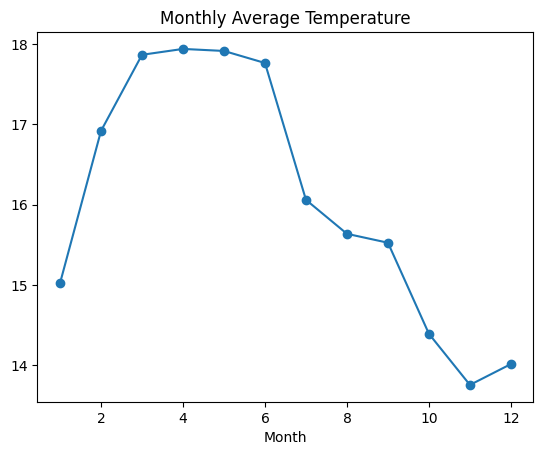

In [19]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line", marker="o")
plt.title("Monthly Average Temperature")
plt.show()

In [20]:
monthly_temp.idxmax(), monthly_temp.max()
monthly_temp.idxmin(), monthly_temp.min()

(11, 13.75560606060606)

Rainfall Trend

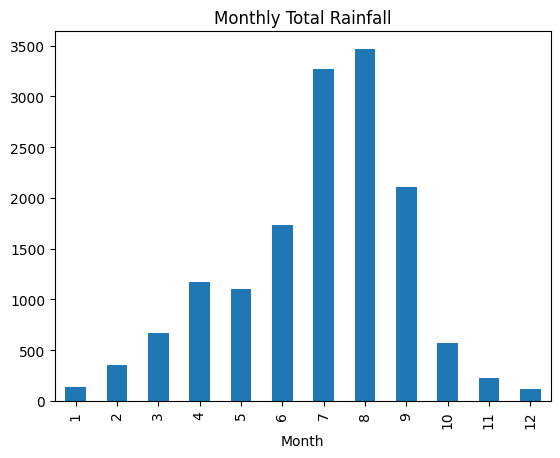

In [21]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall")
plt.show()

Correlation Analysis

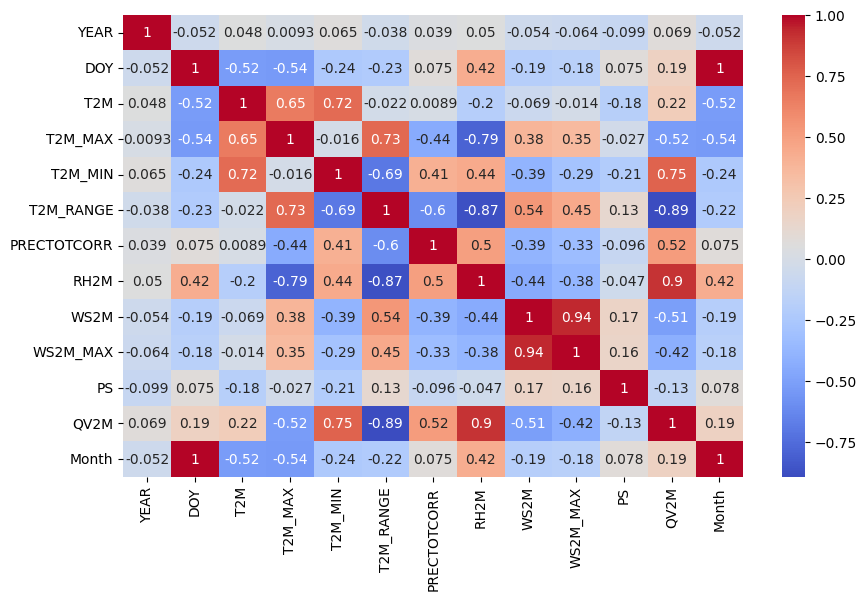

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Scatter plots

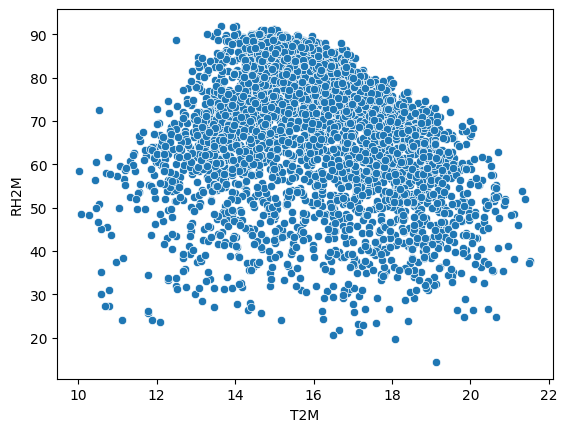

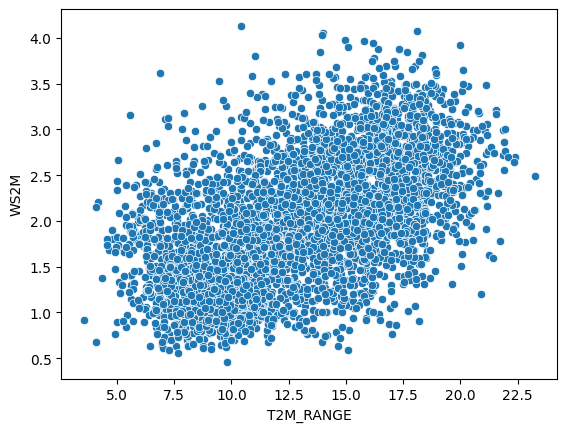

In [23]:
sns.scatterplot(x=df["T2M"], y=df["RH2M"])
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])
plt.show()

Distribution Analysis

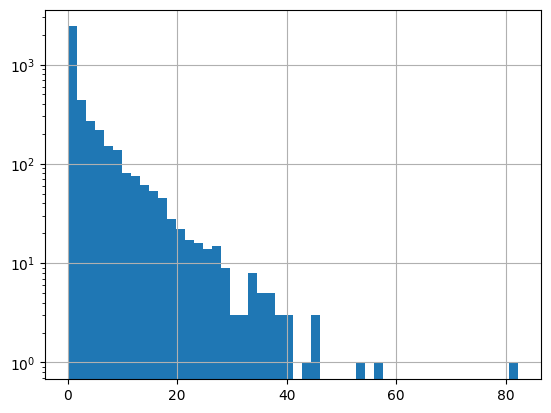

In [24]:
df["PRECTOTCORR"].hist(bins=50)
plt.yscale("log")  # if skewed
plt.show()

Bubble Chart

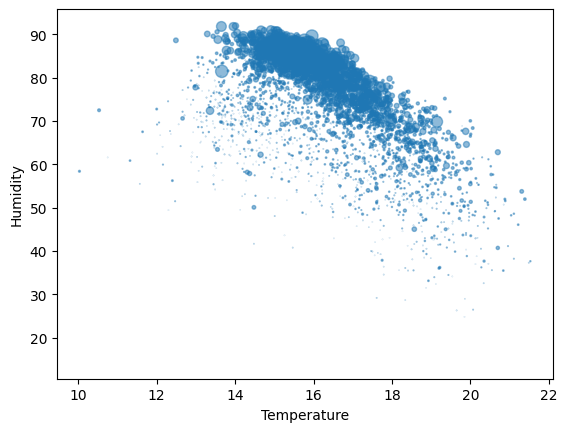

In [25]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*2,
    alpha=0.5
)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()